# 🎵 Exploration préliminaire avec **pandas**

## Charger les données
On utilise `pandas.read_csv` qui charge directement le fichier dans un DataFrame.  
Fini les listes et les index numériques : chaque colonne a un **nom**.

Documentation pandas : https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html

In [307]:
import numpy as np
import pandas as pd
df = pd.read_csv("spotify_songs.csv")


print(df.columns.values)

['alltime_rank' 'song_title' 'artist' 'total_streams_billions'
 'primary_genre' 'bpm' 'release_year' 'artist_country' 'explicit'
 'danceability' 'energy' 'valence' 'acousticness' 'dataset_part']


## Sélectionner des parties des données

### Afficher les deux premières lignes. Que représentent-elles ?

In [308]:
print(df.head(2).T) #T c'est pour pivoter

                                                             0  \
alltime_rank                                                 1   
song_title                                     Blinding Lights   
artist                                              The Weeknd   
total_streams_billions                                    5.26   
primary_genre                                        Synth-Pop   
bpm                                                        171   
release_year                                              2019   
artist_country                                          Canada   
explicit                                                 False   
danceability                                              0.51   
energy                                                     0.8   
valence                                                   0.33   
acousticness                                               0.0   
dataset_part            Spotify All-Time Most Streamed Top 100   

         

### Afficher la seconde colonne de chacune de ces deux lignes

In [321]:

print(df['song_title'][:2])
print(df.loc[:2,'song_title'])

0    Blinding Lights
1       Shape of You
Name: song_title, dtype: object
0      Blinding Lights
1         Shape of You
2    Someone You Loved
Name: song_title, dtype: object


### Afficher le titre de la chanson classée 47ème

In [20]:
print(df[ 'song_title'][46])

Starboy


### Combien de chansons sont produites par le CANADA

**`query()`** exprime un filtre comme une chaîne de caractères lisible.  
C'est particulièrement pratique pour les conditions sur du texte ou des nombres.  
Doc : https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.query.html

In [284]:
print(len(df.query("artist_country.str.contains('Canada')")))

10


### Extraire l'information concernant l'année de sortie
Avec pandas, une colonne entière s'extrait en une ligne — pas besoin de boucle.

In [31]:
print(df[ 'release_year'])

0     2019
1     2017
2     2018
3     2018
4     2016
      ... 
95    2018
96    2020
97    2018
98    2020
99    2014
Name: release_year, Length: 100, dtype: int64


### Afficher les 15 premières et les 5 dernières valeurs

In [297]:
# meme chose
print(df[ 'release_year'][:15])
print(df[ 'release_year'].iloc[-5:])

0     2019
1     2017
2     2018
3     2018
4     2016
5     2021
6     2017
7     2017
8     2019
9     2018
10    2019
11    2019
12    2017
13    2020
14    2020
Name: release_year, dtype: int64
95    2018
96    2020
97    2018
98    2020
99    2014
Name: release_year, dtype: int64


### Quelle est la plus ancienne / la plus récente année de sortie ?

In [35]:
print(df[ 'release_year'].min())
print(df[ 'release_year'].max())

1985
2024


### Combien de chansons sont sorties en 2018 ?

In [37]:
print(len(df.query("release_year == 2018")))

10


### Combien de chansons ont été publiées année par année ?

💡 Astuce : `value_counts()` + `sort_index()`

In [39]:
print(df[ 'release_year'].value_counts().sort_index())

release_year
1985     1
1991     1
1994     1
1996     1
1998     1
2001     1
2002     1
2003     1
2006     1
2012     1
2013     5
2014     5
2015     2
2016     8
2017    10
2018    10
2019    13
2020    10
2021    10
2022     6
2023     4
2024     7
Name: count, dtype: int64


### Nombre moyen de chansons publiées chaque année

In [322]:
# nunique() retourne le nombre de valeurs uniques alors que unique() retourne les valeurs 
print(round(len(df)/ df['release_year'].nunique(),2))

4.55


### Combien de pays différents sont recensés ?

💡 astuce: méthodes intéressantes:

- `.split()`, `.strip()`
- `.explode()`
- `.unique()`

In [326]:
print(len(df['artist_country'].str.replace('NZ','New Zealand').str.split('/').explode().str.strip().unique()))
print(df['artist_country'].str.replace('NZ','New Zealand').str.split('/').explode().str.strip().unique())
print(df['artist_country'].apply(lambda x : x.replace('NZ','New Zealand').split('/')).explode().str.strip().unique())

14
['Canada' 'UK' 'USA' 'Australia' 'Cuba' 'South Korea' 'Nigeria'
 'Puerto Rico' 'Iceland' 'New Zealand' 'Ireland' 'Netherlands' 'Germany'
 'Spain']
['Canada' 'UK' 'USA' 'Australia' 'Cuba' 'South Korea' 'Nigeria'
 'Puerto Rico' 'Iceland' 'New Zealand' 'Ireland' 'Netherlands' 'Germany'
 'Spain']


### Extraire tous les titres des chansons

In [48]:
print(df['song_title'])

0             Blinding Lights
1                Shape of You
2           Someone You Loved
3                   Sunflower
4                   One Dance
               ...           
95                Electricity
96    Blinding Lights (Remix)
97            Falling For You
98        Laugh Now Cry Later
99               Shake It Off
Name: song_title, Length: 100, dtype: object


## Manipuler les structures de données

### Stocker conjointement l'année de sortie et le nom de l'artiste dans un tuple

In [285]:
artist_annee = list(zip(df['release_year'],df['artist']))
print(artist_annee)
#meme chose
print(list(df[['release_year','artist']].itertuples(index =False , name =None)))

[(2019, 'The Weeknd'), (2017, 'Ed Sheeran'), (2018, 'Lewis Capaldi'), (2018, 'Post Malone & Swae Lee'), (2016, 'Drake'), (2021, 'The Kid LAROI & Justin Bieber'), (2017, 'Imagine Dragons'), (2017, 'Post Malone ft. 21 Savage'), (2019, 'Tones and I'), (2018, 'Marshmello & Bastille'), (2019, 'Shawn Mendes & Camila Cabello'), (2019, 'Harry Styles'), (2017, 'Ed Sheeran'), (2020, 'Dua Lipa'), (2020, 'Glass Animals'), (2019, 'Billie Eilish'), (2021, 'Olivia Rodrigo'), (2019, 'Post Malone'), (2019, 'Maroon 5'), (2018, 'Lady Gaga & Bradley Cooper'), (2022, 'Harry Styles'), (2020, 'BTS'), (2023, 'Miley Cyrus'), (2013, 'OneRepublic'), (2018, 'Juice WRLD'), (2016, 'The Chainsmokers ft. Halsey'), (2022, 'Rema & Selena Gomez'), (2022, 'Taylor Swift'), (2020, 'The Weeknd'), (2016, 'The Weeknd'), (2018, 'Billie Eilish & Khalid'), (2014, 'Mark Ronson ft. Bruno Mars'), (2013, 'The Neighbourhood'), (2019, 'Taylor Swift'), (2017, 'Luis Fonsi ft. Daddy Yankee'), (2017, 'Camila Cabello ft. Young Thug'), (202

### (Année de sortie, nombre de chansons) par ordre croissant

In [59]:
#annee_nb = df['release_year'].value_counts().sort_index()
print(list(df.groupby('release_year').size().items()))

[(1985, 1), (1991, 1), (1994, 1), (1996, 1), (1998, 1), (2001, 1), (2002, 1), (2003, 1), (2006, 1), (2012, 1), (2013, 5), (2014, 5), (2015, 2), (2016, 8), (2017, 10), (2018, 10), (2019, 13), (2020, 10), (2021, 10), (2022, 6), (2023, 4), (2024, 7)]


Trier par nombre de chansons (ordre décroissant)

In [85]:
print(list(df.groupby('release_year').size().sort_values(ascending=False).items()))

[(2019, 13), (2020, 10), (2018, 10), (2017, 10), (2021, 10), (2016, 8), (2024, 7), (2022, 6), (2013, 5), (2014, 5), (2023, 4), (2015, 2), (1991, 1), (1985, 1), (2001, 1), (1998, 1), (1996, 1), (1994, 1), (2002, 1), (2003, 1), (2006, 1), (2012, 1)]


### Quel pays a le plus de chansons dans le top 100 ?

In [287]:
#get the country not the max
print(df[ 'artist_country'].value_counts().idxmax())
print(df[ 'artist_country'].mode()[0])

USA
USA


### Quelle est la chanson la plus streamée / la moins streamée ?

In [295]:
print(df['song_title'].where(df['total_streams_billions'] == df['total_streams_billions'].max()).dropna())
print(df['song_title'].where(df['total_streams_billions'] == df['total_streams_billions'].min()).dropna())

print(df.loc[df['total_streams_billions'].idxmax(),'song_title'])
print(df.loc[df['total_streams_billions'].idxmin(),'song_title'])

0    Blinding Lights
Name: song_title, dtype: object
73    Beautiful Things
Name: song_title, dtype: object
Blinding Lights
Beautiful Things


### Histogramme de la distribution des streams

Doc : https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.hist.html

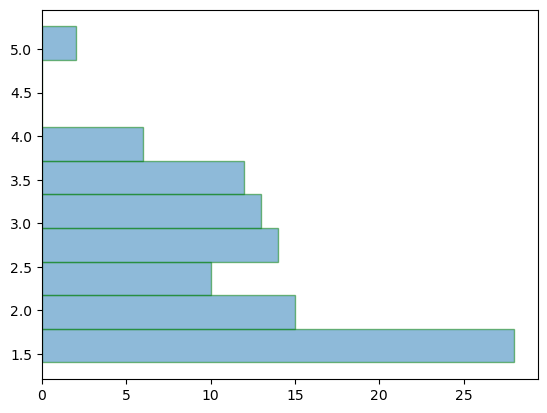

In [113]:
import matplotlib.pyplot as plt

plt.hist(df['total_streams_billions'], histtype = 'bar', orientation = 'horizontal', edgecolor = 'green', alpha = 0.5)
plt.show()

### Indice de "dansabilité" > 80 %

In [137]:
print(df.query("danceability > 0.8")['song_title'])
print(len(df.query("danceability > 0.8")['song_title']))

1            Shape of You
8            Dance Monkey
31            Uptown Funk
43            Not Like Us
76                   APT.
98    Laugh Now Cry Later
Name: song_title, dtype: object
6


### Combien de chansons dépassent 2 milliards de streams ?

In [120]:
print(len(df.query("total_streams_billions > 2.0")))

63


### Créer et sauvegarder un fichier : chansons > 2 Mds streams ET dansabilité > 80 %

In [311]:
df.query("danceability > 0.8 and total_streams_billions > 2.0").to_csv("chansons.csv",index=False)

## Manipulation de dictionnaires et sets — Analyse des artistes

Ressources utiles :  
- Timer : https://ipython.readthedocs.io/en/stable/interactive/magics.html  
- Sets in Python : https://realpython.com/python-sets/  
- Dictionaries in Python : https://realpython.com/python-dicts/

### Identifier tous les artistes uniques (en séparant les collaborations)

In [312]:
# & or ft. or feat.
artists = df['artist'].str.replace('feat.', '&').str.replace('ft.','&').str.split('&').explode().str.strip().unique()
print(artists)
print(len(artists))

['The Weeknd' 'Ed Sheeran' 'Lewis Capaldi' 'Post Malone' 'Swae Lee'
 'Drake' 'The Kid LAROI' 'Justin Bieber' 'Imagine Dragons' '21 Savage'
 'Tones and I' 'Marshmello' 'Bastille' 'Shawn Mendes' 'Camila Cabello'
 'Harry Styles' 'Dua Lipa' 'Glass Animals' 'Billie Eilish'
 'Olivia Rodrigo' 'Maroon 5' 'Lady Gaga' 'Bradley Cooper' 'BTS'
 'Miley Cyrus' 'OneRepublic' 'Juice WRLD' 'The Chainsmokers' 'Halsey'
 'Rema' 'Selena Gomez' 'Taylor Swift' 'Khalid' 'Mark Ronson' 'Bruno Mars'
 'The Neighbourhood' 'Luis Fonsi' 'Daddy Yankee' 'Young Thug' 'Adele'
 'Eminem' 'Linkin Park' 'Nirvana' 'Sabrina Carpenter' 'Kate Bush'
 'Kendrick Lamar' 'Mariah Carey' 'Daft Punk' 'Travis Scott'
 'Ariana Grande' 'One Direction' 'Panic! At The Disco' 'Vance Joy' 'KALEO'
 'Conan Gray' '24kGoldn' 'iann dior' 'Coldplay' 'SAINt JHN' 'JVKE' 'Sia'
 'GAYLE' 'Nicky Youre' 'Dazy' 'Benson Boone' 'Elley Duhé' 'Jawsh 685'
 'Jason Derulo' 'ROSE' 'My Chemical Romance' 'Goo Goo Dolls' 'Masked Wolf'
 'Beyoncé' 'Teddy Swims' 'Hozier' 

### Compter le nombre de chansons par artiste

💡 Astuce: la méthode `value_counts()` peut être utile

In [315]:

#print(df['artist'].value_counts())

print(df['artist'].str.replace('feat.', '&').str.replace('ft.','&').str.split('&').explode().str.strip().value_counts())

artist
The Weeknd         5
Ed Sheeran         5
Harry Styles       5
Post Malone        4
Imagine Dragons    3
                  ..
Silk City          1
Rosalía            1
Peachy             1
mxmtoon            1
Lil Durk           1
Name: count, Length: 91, dtype: int64


### Artiste le plus prolifique

💡 Astuce: la méthode `idxmax()` peut être utile

In [165]:
print(df[ 'artist'].value_counts().idxmax())

Ed Sheeran


### Proportion de collaborations

In [190]:
print(df['artist'].where(df['artist'].str.contains('&') | df['artist'].str.contains('ft.') | df['artist'].str.contains('feat.')).dropna())

3            Post Malone & Swae Lee
5     The Kid LAROI & Justin Bieber
7         Post Malone ft. 21 Savage
9             Marshmello & Bastille
10    Shawn Mendes & Camila Cabello
19       Lady Gaga & Bradley Cooper
25      The Chainsmokers ft. Halsey
26              Rema & Selena Gomez
30           Billie Eilish & Khalid
31       Mark Ronson ft. Bruno Mars
34      Luis Fonsi ft. Daddy Yankee
35    Camila Cabello ft. Young Thug
46         The Weeknd ft. Daft Punk
49           Lady Gaga & Bruno Mars
60           24kGoldn ft. iann dior
64      The Chainsmokers & Coldplay
72               Nicky Youre & Dazy
75         Jawsh 685 & Jason Derulo
76                ROSE & Bruno Mars
80          Beyoncé ft. Post Malone
86     Wiz Khalifa ft. Charlie Puth
89                 Doja Cat ft. SZA
94             Cyril & Violet Skies
95             Silk City & Dua Lipa
96             The Weeknd & Rosalía
97             Peachy feat. mxmtoon
98               Drake ft. Lil Durk
Name: artist, dtype: object


# PARTIE OPTIONNELLE

## Analyse du BPM

In [317]:
print(df['bpm'])

0     171
1      96
2      77
3      93
4     100
     ... 
95    143
96    171
97    150
98    142
99    160
Name: bpm, Length: 100, dtype: int64


### Chansons avec BPM > 140

In [306]:
print(df['song_title'].where(df['bpm'] > 140).dropna())
#meme chose
print(df.query("bpm > 140")['song_title'])

0                     Blinding Lights
5                                Stay
7                            Rockstar
20                          As It Was
33                       Cruel Summer
34                          Despacito
37                      Lose Yourself
44                           good 4 u
45    All I Want for Christmas Is You
46                            Starboy
52                            Thunder
56                         High Hopes
60                               Mood
65                          Positions
71                            abcdefu
76                               APT.
79             Astronaut In The Ocean
93                              Bliss
95                        Electricity
96            Blinding Lights (Remix)
97                    Falling For You
98                Laugh Now Cry Later
99                       Shake It Off
Name: song_title, dtype: object
0                     Blinding Lights
5                                Stay
7                 

### Tuples (track_name, bpm) triés par BPM décroissant

In [206]:
print( list(df[['song_title', 'bpm']].sort_values('bpm', ascending = False).itertuples(index =False , name =None)))

[('High Hopes', 191), ('Starboy', 186), ('Despacito', 178), ('As It Was', 174), ('Blinding Lights (Remix)', 171), ('Lose Yourself', 171), ('Blinding Lights', 171), ('Stay', 170), ('Cruel Summer', 170), ('Thunder', 168), ('good 4 u', 166), ('Shake It Off', 160), ('Rockstar', 159), ('Bliss', 154), ('Mood', 150), ('Falling For You', 150), ('All I Want for Christmas Is You', 150), ('Astronaut In The Ocean', 145), ('APT.', 145), ('abcdefu', 144), ('Positions', 144), ('Electricity', 143), ('Laugh Now Cry Later', 142), ('7 rings', 140), ('Lemon Tree', 139), ('End Of Beginning', 139), ('Sunroof', 138), ('Radioactive', 136), ('Bad Guy', 135), ('Riptide', 131), ('Without Me', 130), ('goosebumps', 130), ('Bad Habits', 126), ('Believer', 125), ('Sweater Weather', 124), ('Counting Stars', 122), ('Circles', 121), ('Die With A Smile', 120), ('Save Your Tears', 118), ('Numb', 118), ('Flowers', 118), ('Smells Like Teen Spirit', 117), ('Senorita', 117), ('Uptown Funk', 115), ('Kiss Me More', 115), ('Dyn

### Visualisation : distribution des BPM

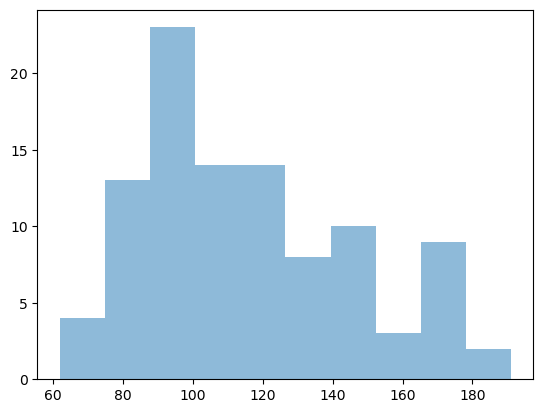

In [209]:
import matplotlib.pyplot as plt

plt.hist(df['bpm'], alpha = 0.5)
plt.show()

### Histogramme du nombre de chansons par année (depuis 2015)

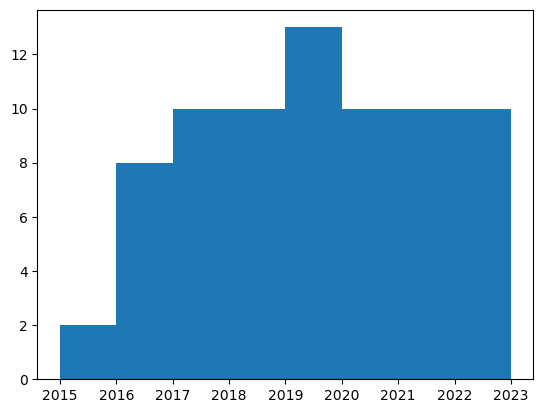

In [257]:
plt.hist(df['release_year'],range(2015,df['release_year'].max()))
plt.show()

### Chansons à la fois très énergétiques (> 0.8) ET très dansables (> 0.7)

In [259]:
# energy & danceability

print(df.query("danceability > 0.7 and energy > 0.8")['song_title'])


31    Uptown Funk
95    Electricity
Name: song_title, dtype: object


### Tuples (track_name, danceability, energy, valence) triés par danceability

In [260]:
print( list(df[['song_title', 'danceability','energy','valence']].sort_values('danceability', ascending = False).itertuples(index =False , name =None)))

[('Uptown Funk', 0.9, 0.96, 0.82), ('APT.', 0.86, 0.79, 0.88), ('Dance Monkey', 0.83, 0.63, 0.73), ('Shape of You', 0.83, 0.65, 0.93), ('Not Like Us', 0.82, 0.72, 0.62), ('Laugh Now Cry Later', 0.82, 0.62, 0.55), ('Espresso', 0.8, 0.73, 0.96), ('Calm Down', 0.8, 0.72, 0.78), ('One Dance', 0.79, 0.62, 0.68), ('Butter', 0.79, 0.73, 0.74), ('Attention', 0.78, 0.68, 0.6), ('Kiss Me More', 0.78, 0.66, 0.8), ('Thinking Out Loud', 0.78, 0.44, 0.46), ('Memories', 0.76, 0.36, 0.7), ('Sunflower', 0.76, 0.49, 0.84), ('Havana', 0.76, 0.58, 0.61), ('Sunroof', 0.76, 0.8, 0.96), ('Electricity', 0.76, 0.88, 0.72), ('Savage Love', 0.76, 0.69, 0.65), ('Senorita', 0.75, 0.74, 0.75), ('Lemon Tree', 0.74, 0.76, 0.86), ('Closer', 0.74, 0.65, 0.77), ('Flowers', 0.74, 0.74, 0.88), ('Positions', 0.74, 0.66, 0.69), ('Dynamite', 0.74, 0.77, 0.74), ("Levii's Jeans", 0.72, 0.65, 0.72), ('Roses', 0.72, 0.62, 0.44), ('Die With A Smile', 0.72, 0.68, 0.55), ('Astronaut In The Ocean', 0.72, 0.79, 0.38), ('Levitating', 